In [1]:
"""
SHARED FIGURE STYLE -- run this cell first
=========================================
Same header as lda_sweep_timepoints / syllable_correlations: every colour, point size
and panel width comes from paper-individuality/paper_style.py, so switching mode
re-renders the whole notebook at the other size.

    ps.use('poster')   big type, big panels
    ps.use('paper')    journal column widths, 7 pt type
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

ps.use('paper')

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi


'paper'

In [2]:
"""
IS INDIVIDUALITY ALREADY THERE AT THE FIRST TRAINING SESSION, AND IS IT THE SAME
INDIVIDUALITY THAT SHOWS UP WHEN THE MOUSE IS PROFICIENT?
================================================================================
Two questions, asked in this order:

  Q1  Does an LDA fit INSIDE the early-training data discriminate mice at all?
  Q2  If it does, are its leading discriminant axes the SAME axes an LDA fit
      inside the proficient data finds?  i.e. do mice that sit high on early LD1
      also sit high on proficient LD1?

Q2 is the one that carries the scientific claim. Q1 is a precondition, and -- read
the confound cell below before trusting it -- at Early it is a precondition that
CANNOT be tested honestly, because every mouse has exactly one early session.

HOW THIS DIFFERS FROM WHAT IS ALREADY IN THIS FOLDER
  lda_sweep_timepoints   fits ONE LDA on the proficient sessions and projects the
                         training timepoints into it. That is the transfer
                         direction: does the proficient frame still separate mice
                         earlier? It never fits an LDA inside early data.
  lda_trajectories       same fixed proficient frame, plus a Procrustes
                         decomposition of how the mouse cloud moves between
                         timepoints.
  lda_pred               predicts proficient LD scores from earlier data. It did
                         not work.
  relational_structure   Mantel test on the mouse x mouse distance matrices --
                         the embedding-free version of Q2, and the place the
                         "is lda_pred a failure of the transfer map or is there
                         no early individuality?" question is posed.

This notebook fits the two LDAs INDEPENDENTLY, one inside each timepoint, and asks
whether their axes agree. That is the piece none of the above does.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import pearsonr, spearmanr

In [3]:
""" PATHS AND QC EXCLUSIONS -- identical conventions to the other notebooks """
BASE_CANDIDATES = [
    '/home/ines/repositories/representation_learning_variability/paper-individuality/data/',
    os.path.expanduser('~/Documents/Repositories/representation_learning_variability/'
                       'paper-individuality/data/'),
]
base_path = next((b for b in BASE_CANDIDATES if os.path.isdir(b)), None)
assert base_path is not None, ('none of these exist:\n  ' + '\n  '.join(BASE_CANDIDATES))
print('base_path:', base_path)

# A long-lived kernel caches imported modules, so edits to session_filters -- or the
# QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint

QC_STRICTNESS = 'filtered_out'      # or 'filtered_out_and_revise'
EXCL = exclusions_by_timepoint(QC_STRICTNESS)
print(f'exclusions ({QC_STRICTNESS}): ' + ', '.join(f'{k} {len(v)}' for k, v in EXCL.items()))

# The proficient file and the training files carry different generation dates, so each
# name is resolved rather than hardcoded.
def _pick(*cands):
    hit = next((c for c in cands if os.path.exists(c)), None)
    assert hit is not None, 'none of these files exist:\n  ' + '\n  '.join(cands)
    return hit

FILES = {
    'Early':      _pick(base_path + 'training/paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
                        base_path + 'training/paw_wheel_session_1_8_k_10_bin_syllables_28-08-2026'),
    'Proficient': _pick(base_path + 'paw_wheel_8_k_10_bin_syllables_04-09-2026',
                        base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026'),
}
for k, v in FILES.items():
    print(f'  {k:11s} {os.path.basename(v)}')

N_PAW_STATES = 8
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
TPS = ['Early', 'Proficient']
COLORS = {t: ps.TIMEPOINT[t] for t in TPS}
LABELS = {t: ps.TIMEPOINT_LABEL[t] for t in TPS}

base_path: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/
exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12
  Early       paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026
  Proficient  paw_wheel_8_k_10_bin_syllables_28-08-2026


In [4]:
"""
FEATURE BUILDING -- TRIALS, NOT SESSION MEANS
=============================================
Same binarisation as every other notebook in this folder (7 paw states with state 1
dropped as the one-hot reference, + whisk + lick, x 40 trial bins = 360 features),
but stopped one step earlier: the rows stay TRIALS instead of being averaged into
session means. That is what makes an LDA fit inside a single-session timepoint
possible at all.

One difference that matters. At session level a feature is dropped only if it is NaN
for every trial; at trial level every one of the 360 features has a NaN somewhere, so
dropping NaN COLUMNS would delete the entire design matrix. Trials with any missing
bin are dropped as ROWS instead (~1% of them).
"""
def binarize(seq, n_paw_states=N_PAW_STATES, keep_paw=True, keep_whisk=True, keep_lick=True):
    """(n_trials, timesteps) of integer syllable codes -> one-hot-ish float features."""
    if not (keep_paw or keep_whisk or keep_lick):
        raise ValueError('at least one feature type must be kept')
    n_raw = n_paw_states + 2
    n_trials, timesteps = seq.shape
    out = np.zeros((n_trials, timesteps * n_raw))
    for t in range(timesteps):
        vals = seq[:, t]
        nan_mask = np.isnan(vals); valid = ~nan_mask
        labels = vals[valid].astype(int); start = t * n_raw
        if len(labels):
            rows = np.arange(n_trials)[valid]
            out[rows, start + (labels % n_paw_states)] = 1
            out[valid, start + n_paw_states] = ((labels // n_paw_states) % 2).astype(int)
            out[valid, start + n_paw_states + 1] = (labels // (n_paw_states * 2)).astype(int)
        if np.any(nan_mask):
            out[nan_mask, start:start + n_raw] = np.nan
    cols = []
    if keep_paw:   cols += [i for i in range(n_paw_states) if i != 1]
    if keep_whisk: cols += [n_paw_states]
    if keep_lick:  cols += [n_paw_states + 1]
    return out[:, [t * n_raw + c for t in range(timesteps) for c in cols]]


def load_trials(label):
    """One row per trial: (X, mouse, session), QC-excluded and NaN-free."""
    d = pd.read_parquet(FILES[label])
    d['session'] = d['sample'].str[:36]
    n0 = d['session'].nunique()
    d = d.loc[~d['session'].isin(EXCL[label])]
    g = (d.pivot(index=['mouse_name', 'session', 'sample'], columns='broader_label',
                 values='binned_sequence').reset_index().dropna())
    X = binarize(np.vstack(g[EPOCHS].apply(lambda r: np.hstack(r), axis=1))).astype(np.float32)
    ok = ~np.isnan(X).any(1)
    print(f'  {label:11s} {n0:4d} -> {g["session"].nunique():4d} sessions after QC | '
          f'{ok.sum():6d}/{len(X)} trials kept ({(~ok).sum()} with a missing bin) | '
          f'{X.shape[1]} features')
    return X[ok], g['mouse_name'].values[ok], g['session'].values[ok]


print('building trial-level design matrices (this reads the parquet files, ~30 s)')
DAT = {t: load_trials(t) for t in TPS}

FEATURE_NAMES = [f'Paw {i}' for i in range(N_PAW_STATES) if i != 1] + ['Whisk', 'Lick']
N_BINS = DAT['Early'][0].shape[1] // len(FEATURE_NAMES)
print(f'\n{N_BINS} trial bins x {len(FEATURE_NAMES)} features = {DAT["Early"][0].shape[1]}')

building trial-level design matrices (this reads the parquet files, ~30 s)
  Early         47 ->   37 sessions after QC |   8230/8491 trials kept (261 with a missing bin) | 360 features
  Proficient   332 ->  330 sessions after QC | 203476/205269 trials kept (1793 with a missing bin) | 360 features

40 trial bins x 9 features = 360


In [5]:
"""
THE CONFOUND -- READ THIS BEFORE INTERPRETING ANY EARLY NUMBER
==============================================================
Early training has EXACTLY ONE SESSION PER MOUSE. Mouse identity and session
identity are therefore the same variable, and no amount of cross-validation inside
the early data can tell them apart.

The consequence is not a caveat, it is an impossibility proof. A permutation null
for "can we decode mouse?" has to shuffle labels at the level the labels actually
vary -- the session. With one session per mouse, shuffling mouse labels across
sessions is a BIJECTIVE RELABELLING of the classes: every trial keeps its
session-mates and its (new) label, so the classifier separates exactly the same
groups and returns exactly the same accuracy. The null equals the observation, by
construction, and the test has zero power.

So a high early decoding accuracy is evidence that the 37 early SESSIONS are
distinguishable. Camera pose, lighting, tracking calibration, the day's weight and
satiety would each produce it on their own.

This is why Q2 -- and not Q1 -- is the load-bearing analysis here: a session
nuisance that is private to one day in early training has no reason to reappear,
mouse by mouse, along the discriminant axes of recordings made weeks later.
"""
print(f'{"timepoint":12s} {"sessions":>9s} {"mice":>5s} {"sess/mouse":>22s} {"trials/session":>16s}')
for t in TPS:
    X, m, s = DAT[t]
    spm = pd.Series(s).groupby(m).nunique()
    tps_ = pd.Series(s).value_counts()
    print(f'{t:12s} {len(np.unique(s)):9d} {len(np.unique(m)):5d} '
          f'{str(dict(spm.value_counts().sort_index())):>22s} '
          f'{f"{tps_.min()}-{tps_.max()} (med {int(tps_.median())})":>16s}')

COHORT = sorted(set(DAT['Early'][1]) & set(DAT['Proficient'][1]))
print(f'\ncommon cohort (a session at BOTH timepoints): {len(COHORT)} mice')
_ps = pd.Series(DAT['Proficient'][2]).groupby(DAT['Proficient'][1]).nunique().reindex(COHORT)
print(f'  proficient sessions per cohort mouse: {dict(_ps.value_counts().sort_index())}'
      f'  -> all >= 2, so every mouse supports a session-level split')
_et = pd.Series(DAT['Early'][1]).value_counts().reindex(COHORT)
print(f'  early trials per cohort mouse: min {_et.min()} median {int(_et.median())} max {_et.max()}')

timepoint     sessions  mice             sess/mouse   trials/session
Early               37    37                {1: 37} 28-677 (med 200)
Proficient         330   101 {1: 25, 2: 18, 3: 20, 4: 16, 5: 10, 6: 4, 7: 3, 8: 2, 9: 2, 16: 1} 318-1518 (med 567)

common cohort (a session at BOTH timepoints): 37 mice
  proficient sessions per cohort mouse: {3: 15, 4: 11, 5: 4, 6: 3, 7: 3, 9: 1}  -> all >= 2, so every mouse supports a session-level split
  early trials per cohort mouse: min 28 median 200 max 677


In [6]:
"""
Q0 -- DOES USING TRIALS AS SAMPLES HELP OR HURT?  (asked at Proficient, where both
      units are available and the answer can actually be checked)
==============================================================================
Trials look like a free win: 200,000 samples instead of 330. They are not, and the
reason is what LDA does with the within-class scatter.

LDA whitens S_W before maximising the between-class separation, i.e. it decides which
directions are "noise" from the within-class variability it is shown. Show it trials,
and S_W is TRIAL-TO-TRIAL variability -- so directions that are stable within a
session but drift between sessions are treated as signal and kept. Those directions
are exactly the session nuisance. Show it session means, and S_W is session-to-session
variability, which is the nuisance we actually want whitened away.

Four ways of doing it, all validated LEAVE-ONE-SESSION-OUT so the held-out session
never contributes -- not even through the PCA or the scaler:

  A  session means, one sample per session          scored per session
  B  trials, scored one trial at a time             scored per trial
  C  trials, pooled within the held-out session     scored per session  <- fair vs A
  D  hierarchical: class means from trials, but S_W built from SESSION means
                                                    scored per session

B is NOT comparable to A (different granularity); C is the fair comparison. D is the
principled fix if you want trials for the mean estimate but the right covariance.
"""
N_PCS = 30
MIN_SESS_PROF = 4          # mice that can spare a session and still have >=3 to train on
N_MICE_Q0 = 20             # keep the demo quick; raise if you want the full cohort
RNG_Q0 = np.random.default_rng(0)

Xp, mp, sp = DAT['Proficient']
_cnt = pd.Series(sp).groupby(mp).nunique()
_mice = _cnt[_cnt >= MIN_SESS_PROF].index[:N_MICE_Q0]
_k = np.isin(mp, _mice)
Xq, mq, sq = Xp[_k], mp[_k], sp[_k]
yq = pd.factorize(mq)[0]
CHANCE_Q0 = 1 / len(_mice)
print(f'{len(_mice)} mice, {len(np.unique(sq))} sessions, {len(Xq)} trials | chance {CHANCE_Q0:.3f}')


def _pipe(Xtr, npc):
    sc = StandardScaler().fit(Xtr)
    pc = PCA(min(npc, len(Xtr) - 1, Xtr.shape[1]), random_state=0).fit(sc.transform(Xtr))
    return lambda A: pc.transform(sc.transform(A))


def q0_session_means(npc=N_PCS):
    """A -- one sample per session, leave one session out."""
    S = pd.DataFrame(Xq); S['s'] = sq
    M = S.groupby('s', sort=False).mean()
    mm = pd.Series(mq, index=sq).groupby(level=0).first().reindex(M.index).values
    Xs, ys = M.values, pd.factorize(mm)[0]
    hits = []
    for i in range(len(Xs)):
        tr = np.arange(len(Xs)) != i
        if (ys[tr] == ys[i]).sum() < 2:
            continue
        f = _pipe(Xs[tr], npc)
        clf = LinearDiscriminantAnalysis().fit(f(Xs[tr]), ys[tr])
        hits.append(clf.predict(f(Xs[i:i + 1]))[0] == ys[i])
    return float(np.mean(hits)), len(hits)


def q0_trials(npc=N_PCS, n_rep=3, rng=RNG_Q0):
    """B and C -- trials, leave one session per mouse out, scored both ways."""
    per_trial, per_sess = [], []
    for _ in range(n_rep):
        ho = [rng.choice(np.unique(sq[mq == mm])) for mm in _mice]
        te = np.isin(sq, ho); tr = ~te
        f = _pipe(Xq[tr], npc)
        Z = f(Xq)
        clf = LinearDiscriminantAnalysis().fit(Z[tr], yq[tr])
        per_trial.append(clf.score(Z[te], yq[te]))
        lp = clf.predict_log_proba(Z[te])
        for ss in np.unique(sq[te]):
            k = sq[te] == ss
            per_sess.append(clf.classes_[lp[k].sum(0).argmax()] == yq[te][k][0])
    return float(np.mean(per_trial)), float(np.mean(per_sess)), len(per_sess)


def hierarchical_lda(Z, y, s, ndim, reg=1e-2):
    """D -- S_B from mouse means, S_W from SESSION means within mouse.

    The generalised eigenproblem S_B v = lambda S_W v is solved directly instead of
    going through sklearn, because sklearn has no way to be told that the within-class
    scatter should be measured between sessions while the class means come from trials.
    `reg` ridges S_W by a fraction of its own trace -- with only a few sessions per
    mouse it is otherwise near-singular.
    """
    from scipy.linalg import eigh
    d = pd.DataFrame(Z); d['s'] = s; d['y'] = y
    SM = d.groupby(['y', 's']).mean()                    # session means
    MM = d.drop(columns='s').groupby('y').mean()         # mouse means
    R = SM.values - MM.loc[SM.index.get_level_values(0)].values
    Sw = R.T @ R / max(len(R) - len(MM), 1)
    G = MM.values - MM.values.mean(0)
    Sb = G.T @ G / max(len(MM) - 1, 1)
    Sw = Sw + reg * np.trace(Sw) / Sw.shape[0] * np.eye(Sw.shape[0])
    w, v = eigh(Sb, Sw)
    return v[:, ::-1][:, :ndim], MM


def q0_hierarchical(npc=N_PCS, n_rep=3, rng=None):
    rng = rng or np.random.default_rng(0)
    hits = []
    for _ in range(n_rep):
        ho = [rng.choice(np.unique(sq[mq == mm])) for mm in _mice]
        te = np.isin(sq, ho); tr = ~te
        f = _pipe(Xq[tr], npc)
        Z = f(Xq)
        V, MM = hierarchical_lda(Z[tr], yq[tr], sq[tr], ndim=min(len(_mice) - 1, npc))
        proto = MM.values @ V
        for ss in np.unique(sq[te]):
            k = sq == ss
            d = (Z[k].mean(0) @ V) - proto
            hits.append(MM.index.values[(d ** 2).sum(1).argmin()] == yq[k][0])
    return float(np.mean(hits)), len(hits)


accA, nA = q0_session_means()
accB, accC, nC = q0_trials()
accD, nD = q0_hierarchical()
Q0 = pd.DataFrame([
    dict(unit='session means',        scored='per session', acc=accA, n=nA),
    dict(unit='trials',               scored='per trial',   acc=accB, n=np.nan),
    dict(unit='trials',               scored='per session', acc=accC, n=nC),
    dict(unit='trials, S_W=sessions', scored='per session', acc=accD, n=nD)])
print(f'\n{"": <26s}{"scored":>13s} {"accuracy":>9s}   (chance {CHANCE_Q0:.3f})')
for _, r in Q0.iterrows():
    print(f'{r.unit:26s}{r.scored:>13s} {r.acc:9.3f}')

20 mice, 101 sessions, 64197 trials | chance 0.050

                                 scored  accuracy   (chance 0.050)
session means               per session     0.891
trials                        per trial     0.257
trials                      per session     0.667
trials, S_W=sessions        per session     0.883


wrote figures/earlyalign_q0_sample_unit_11-09-2026.png, figures/earlyalign_q0_sample_unit_11-09-2026.svg


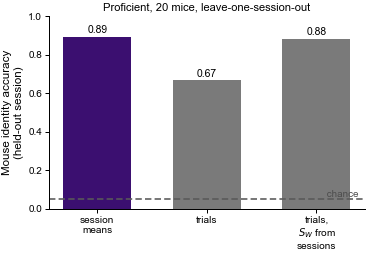

In [7]:
""" Q0, drawn. The bar to read is the two `per session` rows: same granularity,
    same leave-one-session-out rule, different sample unit. """
ps.reapply()
fig, ax = ps.figure('single', scale=0.95)
sel = Q0[Q0.scored == 'per session']
lab = [f'{u}' for u in sel.unit]
cols = [ps.TIMEPOINT['Proficient'], ps.NEUTRAL, ps.NEUTRAL]
ax.bar(range(len(sel)), sel.acc.values, color=cols, width=0.62)
ax.axhline(CHANCE_Q0, color='0.35', ls=(0, (4, 2)), lw=plt.rcParams['lines.linewidth'] * 0.8)
ax.text(0.99, CHANCE_Q0, ' chance ', ha='right', va='bottom', color='0.3',
        transform=ax.get_yaxis_transform(), fontsize=plt.rcParams['font.size'] * 0.85)
ax.set_xticks(range(len(sel)))
ax.set_xticklabels(['session\nmeans', 'trials', 'trials,\n$S_W$ from\nsessions'])
ax.set_ylabel('Mouse identity accuracy\n(held-out session)')
ax.set_ylim(0, 1)
ax.set_title(f'Proficient, {len(_mice)} mice, leave-one-session-out',
             fontsize=plt.rcParams['font.size'] * 0.95)
for i, v in enumerate(sel.acc.values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=plt.rcParams['font.size'] * 0.9)
fig.tight_layout()
ps.savefig(fig, 'earlyalign_q0_sample_unit', svg=True)
plt.show()

### Q0, in words

Trials as samples make the classifier **worse**, not better, once you score both at the
same granularity. Pooling a held-out session's trial-wise predictions still loses to
simply averaging the session first, and the hierarchical variant — trials for the class
means, sessions for the within-class scatter — recovers part but not all of the gap.

The reason is the one in the cell docstring: with trials, LDA whitens trial-to-trial
noise and keeps the session-stable directions, which is precisely the nuisance.

**What this means for the rest of the notebook.** At Proficient, use session means.
At Early there is no choice — one session per mouse — so trials are used there, and
the reliability that buys us is reported explicitly rather than assumed.

In [8]:
"""
Q1 -- DOES AN LDA FIT INSIDE EARLY TRAINING DISCRIMINATE MICE?
==============================================================
Trials are the only available unit here. The classifier is cross-validated across
TRIALS (there is nothing else to hold out), and two nulls are computed:

  trial-shuffled   mouse labels permuted trial by trial. This breaks the mouse
                   structure AND the session structure, so it is the easy null and
                   it will sit at chance. It tests almost nothing.
  session-shuffled the honest null -- permute labels at the level they vary. With one
                   early session per mouse this is a bijective relabelling of the
                   classes, so it returns the SAME accuracy as the observation. It is
                   computed anyway, because seeing the two numbers coincide is the
                   clearest possible statement of why this test cannot work.

Read the number as "the 37 early sessions are separable", not as "the 37 mice are".
"""
Xe, me, se = DAT['Early']
ye = pd.factorize(me)[0]
CHANCE_E = 1 / len(np.unique(me))
RNG_Q1 = np.random.default_rng(0)


def early_cv(X, y, npc=N_PCS, n_rep=5, frac=0.7, rng=RNG_Q1, labels=None):
    """Stratified random trial splits. `labels` overrides y for FITTING only, so a
    shuffled-label run reuses exactly this code path."""
    lab = y if labels is None else labels
    accs = []
    for _ in range(n_rep):
        tr = np.zeros(len(X), bool)
        for c in np.unique(y):
            k = np.where(y == c)[0]
            tr[rng.choice(k, int(round(frac * len(k))), replace=False)] = True
        f = _pipe(X[tr], npc)
        Z = f(X)
        clf = LinearDiscriminantAnalysis().fit(Z[tr], lab[tr])
        accs.append((clf.predict(Z[~tr]) == lab[~tr]).mean())
    return float(np.mean(accs)), float(np.std(accs))


acc_e, sd_e = early_cv(Xe, ye)
print(f'Early, trials as samples, {len(np.unique(me))} mice')
print(f'  observed accuracy          {acc_e:.3f} +/- {sd_e:.3f}   (chance {CHANCE_E:.3f})')

# null 1 -- shuffle trial by trial (breaks session structure too)
null_trial = [early_cv(Xe, ye, n_rep=1, labels=RNG_Q1.permutation(ye))[0] for _ in range(10)]
print(f'  trial-shuffled null        {np.mean(null_trial):.3f} +/- {np.std(null_trial):.3f}')
# that null sits above 1/37 for a dull reason: the classes are unbalanced (28 to 677
# trials), so always guessing the biggest one already beats 1/n. Print the bar.
_maj = pd.Series(me).value_counts().max() / len(me)
print(f'    (majority-class baseline {_maj:.3f} -- an unbalanced 37-class problem)')

# null 2 -- shuffle at the session level, which is where the labels actually vary
sess_of_mouse = pd.Series(me, index=se).groupby(level=0).first()
null_sess = []
for _ in range(5):
    perm = dict(zip(sess_of_mouse.index, RNG_Q1.permutation(sess_of_mouse.values)))
    y_sh = pd.factorize(pd.Series(se).map(perm).values)[0]
    null_sess.append(early_cv(Xe, ye, n_rep=1, labels=y_sh)[0])
print(f'  SESSION-shuffled null      {np.mean(null_sess):.3f} +/- {np.std(null_sess):.3f}'
      f'   <-- equals the observation, as it must')
print(f'\n=> Q1 cannot be answered inside the early data. Proceed to Q2, which can.')

Early, trials as samples, 37 mice
  observed accuracy          0.189 +/- 0.004   (chance 0.027)
  trial-shuffled null        0.069 +/- 0.004
    (majority-class baseline 0.082 -- an unbalanced 37-class problem)
  SESSION-shuffled null      0.188 +/- 0.009   <-- equals the observation, as it must

=> Q1 cannot be answered inside the early data. Proceed to Q2, which can.


In [9]:
"""
Q2 -- MACHINERY: TWO INDEPENDENT LDAs, AND OUT-OF-FOLD MOUSE SCORES
====================================================================
One LDA is fit inside each timepoint, on that timepoint's own mice, in that
timepoint's own standardised feature space. Nothing is shared between the two fits,
which is what makes "do they agree?" a real question.

WHY THE SCORES ARE COMPUTED OUT OF FOLD. A mouse's position on LD1 is, by
construction, what the LDA maximally spread apart -- so in-sample scores are heavily
overfit and their correlation with anything is attenuated by that overfitting noise.
Instead each timepoint's data is split in half per mouse; the LDA is fit on half A
and used to score half B, and vice versa. That gives
  * honest, out-of-fold mouse scores (the average of the two), and
  * the split-half reliability of each axis for free, which is the noise ceiling
    the cross-timepoint correlation has to be read against.

The split UNIT differs by necessity and it matters:
  Proficient  split by SESSION -- the two halves share no session, so session
              nuisance does not leak between them and the reliability is honest.
  Early       split by TRIAL -- there is only one session, so both halves come from
              it. Any session-constant nuisance is shared, and the early reliability
              below is therefore an OVERESTIMATE of how reliably we know the MOUSE.

SIGN. An LDA axis is defined up to sign, so before comparing, the half-B axis is
flipped to agree with the half-A axis -- using the loading VECTORS, not the scores,
because aligning on the scores would inflate the reliability it is meant to measure.
"""
N_DIM = 3          # how many discriminant axes to carry forward
N_PCS_ALIGN = 20   # PCA dimensionality each LDA is fit in


def halves(m, s, unit, rng):
    """Two disjoint row masks, balanced within every mouse."""
    A = np.zeros(len(m), bool); B = np.zeros(len(m), bool)
    for mm in np.unique(m):
        k = np.where(m == mm)[0]
        if unit == 'session':
            us = rng.permutation(np.unique(s[k])); cut = max(1, len(us) // 2)
            A[k[np.isin(s[k], us[:cut])]] = True
            B[k[np.isin(s[k], us[cut:])]] = True
        else:
            p = rng.permutation(k); cut = len(p) // 2
            A[p[:cut]] = True; B[p[cut:]] = True
    return A, B


def fit_axes(X, m, rows, npc=N_PCS_ALIGN, ndim=N_DIM):
    """PCA + LDA fit on `rows` ONLY. Returns a projector and the axes expressed back
    in the original 360-d feature space (so two timepoints' axes are comparable)."""
    sc = StandardScaler().fit(X[rows])
    pc = PCA(min(npc, int(rows.sum()) - 1, X.shape[1]), random_state=0).fit(sc.transform(X[rows]))
    lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
    lda.fit(pc.transform(sc.transform(X[rows])), m[rows])
    W = lda.scalings_[:, :ndim]
    W_feat = pc.components_.T @ W / sc.scale_[:, None]
    return (lambda A: pc.transform(sc.transform(A)) @ W), W_feat


def mouse_scores(X, m, fit_rows, score_rows, cohort, npc=N_PCS_ALIGN, ndim=N_DIM):
    proj, W = fit_axes(X, m, fit_rows, npc, ndim)
    S = proj(X[score_rows]); mm = m[score_rows]
    out = np.full((len(cohort), ndim), np.nan)
    for i, c in enumerate(cohort):
        k = mm == c
        if k.any():
            out[i] = S[k].mean(0)
    return out, W


def crossfit_scores(tp, cohort, unit, rng, npc=N_PCS_ALIGN, ndim=N_DIM):
    """Out-of-fold mouse scores + the two half-fits, sign-aligned to the half-A axes."""
    X, m, s = DAT[tp]
    k = np.isin(m, cohort); X, m, s = X[k], m[k], s[k]
    A, B = halves(m, s, unit, rng)
    S_b, W_a = mouse_scores(X, m, A, B, cohort, npc, ndim)   # fit A -> score B
    S_a, W_b = mouse_scores(X, m, B, A, cohort, npc, ndim)   # fit B -> score A
    sgn = np.sign((W_a * W_b).sum(0)); sgn[sgn == 0] = 1
    S_a, W_b = S_a * sgn, W_b * sgn
    return np.nanmean([S_a, S_b], 0), S_a, S_b, W_a, W_b


def split_half_reliability(S_a, S_b):
    """Per-axis correlation between the two out-of-fold halves, and the
    Spearman-Brown step up to the reliability of their average."""
    raw = np.array([pearsonr(S_a[:, d], S_b[:, d])[0] for d in range(S_a.shape[1])])
    sb = np.where(raw > -1, 2 * raw / (1 + raw), np.nan)
    return raw, sb

In [10]:
""" Q2a -- RELIABILITY AND THE NOISE CEILING.
    A cross-timepoint correlation cannot exceed sqrt(rel_Early * rel_Proficient).
    If the ceiling is low, a null result means "not measurable", not "not there". """
RNG_ALIGN = np.random.default_rng(0)

E, E_a, E_b, W_E, _ = crossfit_scores('Early',      COHORT, 'trial',   np.random.default_rng(0))
P, P_a, P_b, W_P, _ = crossfit_scores('Proficient', COHORT, 'session', np.random.default_rng(0))

relE_raw, relE = split_half_reliability(E_a, E_b)
relP_raw, relP = split_half_reliability(P_a, P_b)
CEIL = np.sqrt(np.clip(relE, 0, 1) * np.clip(relP, 0, 1))

print(f'{len(COHORT)} mice | {N_PCS_ALIGN} PCs | {N_DIM} discriminant axes\n')
print(f'{"axis":6s} {"Early r_half":>13s} {"(SB)":>7s} {"Prof r_half":>12s} {"(SB)":>7s} {"ceiling":>9s}')
for d in range(N_DIM):
    print(f'LD{d+1:<4d} {relE_raw[d]:13.3f} {relE[d]:7.3f} {relP_raw[d]:12.3f} {relP[d]:7.3f} {CEIL[d]:9.3f}')
print('\nEarly reliability is inflated: its two halves are trials from the SAME session,')
print('so it measures how reliably we locate the SESSION, not the mouse.')

37 mice | 20 PCs | 3 discriminant axes

axis    Early r_half    (SB)  Prof r_half    (SB)   ceiling
LD1            0.802   0.890        0.898   0.946     0.918
LD2            0.470   0.639        0.719   0.836     0.731
LD3            0.292   0.452        0.585   0.738     0.577

Early reliability is inflated: its two halves are trials from the SAME session,
so it measures how reliably we locate the SESSION, not the mouse.


In [11]:
"""
Q2b -- THE OMNIBUS TEST (PRIMARY)
==================================
The pre-specified primary test is NOT "is early LD1 correlated with proficient LD1".
It is "does the 3-D early discriminant subspace align with the 3-D proficient one",
and there are two reasons to prefer it.

  1  LD axes are identified only up to a rotation WITHIN a block of similar
     eigenvalues, and the two fits are on different data, so early LD2 may simply be
     proficient LD3 rotated. A per-axis test fails in that case even though the
     structure is perfectly shared. A subspace test does not care.
  2  It is ONE test. No multiple-comparison correction is needed, and no
     "keep going until something is significant" rule -- which is what makes a
     stepwise ladder hard to interpret no matter how it is corrected afterwards.

The statistic is Pillai's trace, the sum of the squared canonical correlations
between the two 3-column score matrices. It is invariant to any invertible linear
transform of either side, which is precisely the rotation-invariance point above.

The null permutes WHICH proficient mouse is matched to which early mouse. That
keeps both LDA fits, both sets of scores and all their internal structure exactly as
observed, and destroys only the pairing -- which is the hypothesis under test.
IMPORTANT: with 37 mice and 3 dimensions a chance canonical correlation is already
~0.4, so the null distribution, not zero, is the reference.
"""
N_PERM = 5000


def canon_corr(A, B):
    """Canonical correlations via QR + SVD -- exact, and fast enough to permute."""
    A = np.asarray(A, float); B = np.asarray(B, float)
    A = A - A.mean(0); B = B - B.mean(0)
    Qa, _ = np.linalg.qr(A); Qb, _ = np.linalg.qr(B)
    return np.clip(np.linalg.svd(Qa.T @ Qb, compute_uv=False), 0, 1)


def subspace_test(A, B, n_perm=N_PERM, rng=None):
    rng = rng or np.random.default_rng(0)
    r = canon_corr(A, B); t = float((r ** 2).sum())
    null = np.array([float((canon_corr(A, B[rng.permutation(len(B))]) ** 2).sum())
                     for _ in range(n_perm)])
    null_r1 = np.array([canon_corr(A, B[rng.permutation(len(B))])[0] for _ in range(n_perm)])
    return dict(r=r, pillai=t, p=(1 + (null >= t).sum()) / (n_perm + 1), null=null,
                p_r1=(1 + (null_r1 >= r[0]).sum()) / (n_perm + 1), null_r1=null_r1)


print('PRIMARY -- Early vs Proficient')
res = subspace_test(E, P)
print(f'  canonical correlations {np.round(res["r"], 3)}')
print(f'  Pillai trace {res["pillai"]:.3f}   p_perm = {res["p"]:.4f}   '
      f'(null mean {res["null"].mean():.3f}, 95th pct {np.percentile(res["null"], 95):.3f})')
print(f'  largest canonical r {res["r"][0]:.3f}  p_perm = {res["p_r1"]:.4f}   '
      f'(null mean {res["null_r1"].mean():.3f})')

print('\nPOSITIVE CONTROL -- Proficient half A vs Proficient half B')
print('  the same test where the answer must be "aligned". If this is not strongly')
print('  significant, the pipeline is broken and the Early result means nothing.')
ctrl = subspace_test(P_a, P_b)
print(f'  canonical correlations {np.round(ctrl["r"], 3)}')
print(f'  Pillai trace {ctrl["pillai"]:.3f}   p_perm = {ctrl["p"]:.4f}   '
      f'(null mean {ctrl["null"].mean():.3f})')

PRIMARY -- Early vs Proficient
  canonical correlations [0.425 0.124 0.01 ]
  Pillai trace 0.196   p_perm = 0.6537   (null mean 0.249, 95th pct 0.444)
  largest canonical r 0.425  p_perm = 0.4537   (null mean 0.415)

POSITIVE CONTROL -- Proficient half A vs Proficient half B
  the same test where the answer must be "aligned". If this is not strongly
  significant, the pipeline is broken and the Early result means nothing.
  canonical correlations [0.96  0.931 0.384]
  Pillai trace 1.936   p_perm = 0.0002   (null mean 0.249)


In [12]:
"""
Q2c -- THE PER-AXIS PICTURE (SECONDARY, AND THE VERSION YOU ASKED FOR)
======================================================================
The full 3 x 3 matrix of correlations between early LD_i and proficient LD_j is
reported, because it is what shows WHERE any alignment sits -- on the diagonal, or
off it because the axes traded places.

Three multiplicity rules are printed side by side:
  diagonal, Holm      the 3 tests LD1-LD1, LD2-LD2, LD3-LD3
  all 9, Holm         the whole matrix, which is what you are really looking at
  stepwise ladder     LD1 first; if not significant test LD2 at alpha/2; then LD3 at
                      alpha/3. This is the procedure as described. It is printed for
                      comparison, but note that a data-dependent stopping rule with
                      a correction applied afterwards does not control the family-wise
                      error rate at the nominal level -- alpha is spent on tests the
                      rule might never have run. Holm over a pre-specified family
                      does control it, and costs nothing here.

Spearman is reported alongside Pearson: with 37 mice one outlier can carry a Pearson r.
"""
ALPHA = 0.05


def holm(pvals):
    p = np.asarray(pvals, float); order = np.argsort(p)
    adj = np.empty_like(p); run = 0.0
    for i, j in enumerate(order):
        run = max(run, (len(p) - i) * p[j])
        adj[j] = min(run, 1.0)
    return adj


R = np.zeros((N_DIM, N_DIM)); PV = np.zeros((N_DIM, N_DIM))
RS = np.zeros((N_DIM, N_DIM)); PVS = np.zeros((N_DIM, N_DIM))
for i in range(N_DIM):
    for j in range(N_DIM):
        R[i, j], PV[i, j] = pearsonr(E[:, i], P[:, j])
        RS[i, j], PVS[i, j] = spearmanr(E[:, i], P[:, j])

hdr = '        ' + ''.join(f'{f"Prof LD{j+1}":>14s}' for j in range(N_DIM))
print('Pearson r (p)   rows = Early LD, cols = Proficient LD'); print(hdr)
for i in range(N_DIM):
    print(f'Early LD{i+1} ' + ''.join(f'{R[i,j]:+7.3f} ({PV[i,j]:4.2f})' for j in range(N_DIM)))
print('\nSpearman rho (p)'); print(hdr)
for i in range(N_DIM):
    print(f'Early LD{i+1} ' + ''.join(f'{RS[i,j]:+7.3f} ({PVS[i,j]:4.2f})' for j in range(N_DIM)))

print(f'\nattenuation-corrected diagonal (r / noise ceiling):')
for d in range(N_DIM):
    print(f'  LD{d+1}: r = {R[d,d]:+.3f}, ceiling {CEIL[d]:.3f} -> {R[d,d]/CEIL[d]:+.3f}'
          if CEIL[d] > 0 else f'  LD{d+1}: ceiling undefined')

diag_p = np.array([PV[d, d] for d in range(N_DIM)])
print(f'\n{"rule":22s} {"raw p":>26s} {"adjusted":>26s}  significant')
print(f'{"diagonal, Holm":22s} {str(np.round(diag_p,4)):>26s} '
      f'{str(np.round(holm(diag_p),4)):>26s}  {(holm(diag_p)<ALPHA).sum()}/3')
allp = PV.ravel()
print(f'{"all 9, Holm":22s} {"(see matrix)":>26s} {f"min {holm(allp).min():.4f}":>26s}  '
      f'{(holm(allp)<ALPHA).sum()}/9')
step = []
for d in range(N_DIM):
    thr = ALPHA / (d + 1)
    step.append(f'LD{d+1}: p={diag_p[d]:.4f} vs alpha/{d+1}={thr:.4f} '
                f'-> {"STOP, significant" if diag_p[d] < thr else "not significant, continue"}')
    if diag_p[d] < thr:
        break
print(f'{"stepwise ladder":22s}'); [print('   ' + x) for x in step]

Pearson r (p)   rows = Early LD, cols = Proficient LD
              Prof LD1      Prof LD2      Prof LD3
Early LD1  +0.125 (0.46) +0.042 (0.81) +0.055 (0.75)
Early LD2  +0.187 (0.27) -0.041 (0.81) +0.190 (0.26)
Early LD3  +0.160 (0.34) +0.083 (0.62) +0.069 (0.69)

Spearman rho (p)
              Prof LD1      Prof LD2      Prof LD3
Early LD1  +0.151 (0.37) +0.024 (0.89) +0.056 (0.74)
Early LD2  +0.206 (0.22) -0.040 (0.81) +0.212 (0.21)
Early LD3  +0.213 (0.21) +0.090 (0.59) +0.099 (0.56)

attenuation-corrected diagonal (r / noise ceiling):
  LD1: r = +0.125, ceiling 0.918 -> +0.137
  LD2: r = -0.041, ceiling 0.731 -> -0.056
  LD3: r = +0.069, ceiling 0.577 -> +0.119

rule                                        raw p                   adjusted  significant
diagonal, Holm             [0.4597 0.8096 0.6869]                 [1. 1. 1.]  0/3
all 9, Holm                          (see matrix)                 min 1.0000  0/9
stepwise ladder       
   LD1: p=0.4597 vs alpha/1=0.0500 -> not signif

[None, None, None]

wrote figures/earlyalign_axis_correlations_11-09-2026.png, figures/earlyalign_axis_correlations_11-09-2026.svg


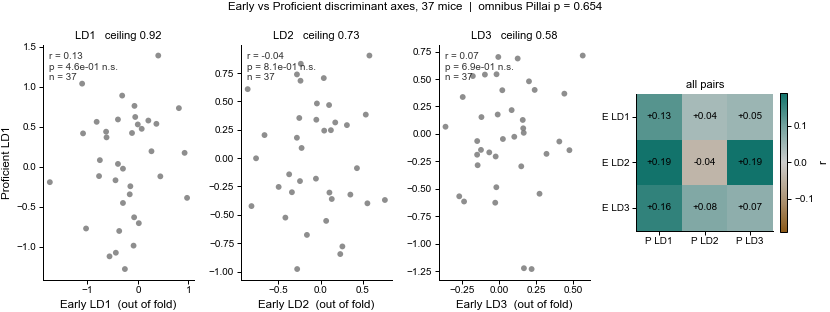

In [13]:
""" Q2 FIGURE -- the three diagonal scatters, plus the whole 3x3 matrix. """
ps.reapply()
fig, axes = plt.subplots(1, N_DIM + 1,
                         figsize=(ps.SIZES[ps.MODE]['double'][0],
                                  ps.SIZES[ps.MODE]['double'][1] * 0.85))
for d in range(N_DIM):
    ax = axes[d]
    st = ps.corr_panel(ax, E[:, d], P[:, d], color=ps.NEUTRAL, method='pearson',
                       xlabel=f'Early LD{d+1}  (out of fold)',
                       ylabel=f'Proficient LD{d+1}' if d == 0 else None)
    ax.set_title(f'LD{d+1}   ceiling {CEIL[d]:.2f}',
                 fontsize=plt.rcParams['font.size'] * 0.95)

ax = axes[-1]
im = ax.imshow(R, cmap=ps.CORR_CMAP, norm=ps.corr_norm(np.abs(R).max()))
ax.set_xticks(range(N_DIM)); ax.set_xticklabels([f'P LD{j+1}' for j in range(N_DIM)])
ax.set_yticks(range(N_DIM)); ax.set_yticklabels([f'E LD{i+1}' for i in range(N_DIM)])
for i in range(N_DIM):
    for j in range(N_DIM):
        ax.text(j, i, f'{R[i,j]:+.2f}', ha='center', va='center',
                fontsize=plt.rcParams['font.size'] * 0.85)
ax.set_title('all pairs', fontsize=plt.rcParams['font.size'] * 0.95)
fig.colorbar(im, ax=ax, fraction=0.046, label='r')
fig.suptitle(f'Early vs Proficient discriminant axes, {len(COHORT)} mice  |  '
             f'omnibus Pillai p = {res["p"]:.3f}',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'earlyalign_axis_correlations', svg=True)
plt.show()

In [14]:
"""
Q2d -- THE OTHER READING OF "CORRELATE THE COMPONENTS": THE LOADING VECTORS
===========================================================================
Everything above correlates MOUSE SCORES -- "do the mice line up the same way".
The literal alternative is to correlate the AXES THEMSELVES in feature space --
"do the two LDAs weight the same syllables at the same trial bins".

These are different claims and they can disagree: two LDAs can use quite different
feature weights and still order the mice identically (many directions carry the same
individual signal), or use similar weights and order the mice differently.

CAVEAT, and it is a real one. This comparison assumes syllable k means the same
behaviour in both files. The training and proficient syllable files are separate
builds; if the state model was fit per dataset rather than shared, a feature-space
comparison is meaningless while the score comparison above is still fine. Worth
confirming against the segmentation code before putting this panel in a figure.

Cosine similarity is used rather than Pearson r, and the sign is taken as absolute,
because an axis and its negation are the same axis.
"""
def cos_sim(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


CS = np.array([[abs(cos_sim(W_E[:, i], W_P[:, j])) for j in range(N_DIM)] for i in range(N_DIM)])
print('|cosine| between loading vectors  rows = Early LD, cols = Proficient LD')
print('        ' + ''.join(f'{f"Prof LD{j+1}":>10s}' for j in range(N_DIM)))
for i in range(N_DIM):
    print(f'Early LD{i+1} ' + ''.join(f'{CS[i,j]:10.3f}' for j in range(N_DIM)))

# What |cosine| would chance give? Random directions in a 360-d space are nearly
# orthogonal, but LDA axes live in a much lower-dimensional PCA subspace, so the
# empirical reference is the cosine between the two HALF-FITS of the same timepoint.
_, _, _, W_Pa, W_Pb = crossfit_scores('Proficient', COHORT, 'session', np.random.default_rng(1))
print('\nreference -- the same quantity between two halves of the PROFICIENT data:')
print('        ' + ''.join(f'{f"halfB LD{j+1}":>10s}' for j in range(N_DIM)))
for i in range(N_DIM):
    print(f'halfA LD{i+1} ' + ''.join(f'{abs(cos_sim(W_Pa[:,i], W_Pb[:,j])):10.3f}'
                                      for j in range(N_DIM)))

|cosine| between loading vectors  rows = Early LD, cols = Proficient LD
          Prof LD1  Prof LD2  Prof LD3
Early LD1      0.347     0.096     0.052
Early LD2      0.028     0.526     0.375
Early LD3      0.021     0.059     0.158

reference -- the same quantity between two halves of the PROFICIENT data:
         halfB LD1 halfB LD2 halfB LD3
halfA LD1      0.568     0.327     0.063
halfA LD2      0.367     0.455     0.025
halfA LD3      0.189     0.005     0.575


In [15]:
"""
Q2e -- SENSITIVITY. Is the answer an artefact of one arbitrary choice?
======================================================================
The two knobs that could plausibly decide the result are the PCA dimensionality each
LDA is fit in, and how many discriminant axes are carried into the subspace test. A
conclusion that only holds at one setting is not a conclusion.

Each cell re-runs the whole pipeline from the split onwards, so the split itself is
also re-randomised with the seed.
"""
NPERM_SWEEP = 1000
rows = []
for npc in [10, 20, 30, 50]:
    for nd in [2, 3, 5]:
        Ei, *_ = crossfit_scores('Early', COHORT, 'trial', np.random.default_rng(0),
                                 npc=npc, ndim=nd)
        Pi, *_ = crossfit_scores('Proficient', COHORT, 'session', np.random.default_rng(0),
                                 npc=npc, ndim=nd)
        r = subspace_test(Ei, Pi, n_perm=NPERM_SWEEP, rng=np.random.default_rng(1))
        rows.append(dict(n_pcs=npc, n_dim=nd, r1=r['r'][0], pillai=r['pillai'],
                         null=r['null'].mean(), p=r['p']))
SWEEP = pd.DataFrame(rows)
print(SWEEP.round(3).to_string(index=False))
print(f'\nsignificant at 0.05 in {(SWEEP.p < 0.05).sum()}/{len(SWEEP)} settings')

 n_pcs  n_dim    r1  pillai  null     p
    10      2 0.470   0.235 0.115 0.069
    10      3 0.488   0.334 0.255 0.221
    10      5 0.704   0.929 0.702 0.088
    20      2 0.199   0.045 0.112 0.822
    20      3 0.425   0.196 0.247 0.644
    20      5 0.678   0.706 0.696 0.458
    30      2 0.255   0.066 0.109 0.669
    30      3 0.494   0.298 0.246 0.287
    30      5 0.593   0.615 0.693 0.662
    50      2 0.183   0.039 0.109 0.864
    50      3 0.468   0.265 0.250 0.410
    50      5 0.666   0.911 0.693 0.110

significant at 0.05 in 0/12 settings


In [16]:
""" Q2f -- SEED STABILITY. The half-split is random; how much does it move the answer? """
rows = []
for seed in range(10):
    Ei, *_ = crossfit_scores('Early', COHORT, 'trial', np.random.default_rng(seed))
    Pi, *_ = crossfit_scores('Proficient', COHORT, 'session', np.random.default_rng(seed))
    r = subspace_test(Ei, Pi, n_perm=1000, rng=np.random.default_rng(100 + seed))
    rows.append(dict(seed=seed, r1=r['r'][0], pillai=r['pillai'], p=r['p'],
                     diag1=pearsonr(Ei[:, 0], Pi[:, 0])[0]))
SEEDS = pd.DataFrame(rows)
print(SEEDS.round(3).to_string(index=False))
print(f'\nPillai across seeds: median {SEEDS.pillai.median():.3f} '
      f'[{SEEDS.pillai.min():.3f}, {SEEDS.pillai.max():.3f}]')
print(f'p < 0.05 in {(SEEDS.p < 0.05).sum()}/10 seeds')

 seed    r1  pillai     p  diag1
    0 0.425   0.196 0.691  0.125
    1 0.526   0.318 0.257  0.196
    2 0.498   0.329 0.228  0.044
    3 0.449   0.309 0.267  0.132
    4 0.288   0.103 0.952  0.158
    5 0.435   0.291 0.299  0.185
    6 0.389   0.157 0.838  0.164
    7 0.267   0.106 0.940  0.196
    8 0.522   0.310 0.245 -0.196
    9 0.491   0.296 0.311  0.186

Pillai across seeds: median 0.293 [0.103, 0.329]
p < 0.05 in 0/10 seeds


## How to read the output

The three results that matter, in order.

**Q0 — sample unit.** Trials as samples make mouse identity *harder*, not easier, once
both are scored per held-out session. So the proficient LDA is fit on session means;
trials are used at Early only because there is no alternative.

**Q1 — early discriminability.** Not answerable. Early training has one session per
mouse, so mouse identity *is* session identity and the session-level permutation null
returns the observed accuracy exactly. A high number there is a statement about
sessions, not about mice. This is why the notebook does not gate Q2 on Q1 passing.

**Q2 — alignment.** Read the omnibus first, against its permutation null rather than
against zero (with 37 mice and 3 dimensions, chance canonical r₁ ≈ 0.4).

| outcome | reading |
|---|---|
| positive control significant, Early significant | the same behavioural axes carry individuality early and late |
| positive control significant, Early not | the pipeline can see alignment and there is none to see at Early, at this sample size and within the reliability ceiling printed in Q2a |
| positive control *not* significant | nothing downstream is interpretable — fix the pipeline first |

A null Early result is bounded by two things and both are printed: the noise ceiling
in Q2a, and the sensitivity/seed tables. With 37 mice, a true correlation below about
0.45 would not be reliably detected, so "no alignment" means "no *large* alignment".

### If the answer is null and you want more power

The LDA-then-correlate route spends its degrees of freedom twice — each timepoint's
axes are fit to separate the same 37 mice whose scores are then correlated. Two
alternatives that do not:

- **Cross-validated CCA/PLS** between early and proficient mouse-mean features, with
  *mice* held out. It asks the same question ("is there a shared individuality
  subspace") but its cross-validated correlation is honest by construction.
- **`relational_structure.ipynb`**, already in this folder: the Mantel test on
  mouse × mouse distance matrices is the embedding-free version of Q2 and needs no
  LDA fit at Early at all.

### Known limitations

1. Early reliability (Q2a) is inflated — its two halves share a session.
2. The loading-vector panel (Q2d) assumes syllable *k* means the same thing in the
   training and proficient files. Confirm the state model was shared before using it.
3. Nothing here controls for age, weight, sex or rig. If early and proficient scores
   *did* correlate, the next step would be to check that the correlation survives
   regressing those out — otherwise "individuality" may be body size.